In [20]:
using StatsBase
using TypedTables
using BenchmarkTools
using Distributions
using YAML
using PrettyPrint
using LinearAlgebra
using Dates
using Plots
using TableView
using CSV
using Revise
Revise.revise()
#using PlotlyBase

In [3]:
using CovidSim_ilm

[ Info: For saving to png with the Plotly backend PlotlyBase has to be installed.


In [4]:
cs = CovidSim_ilm

CovidSim_ilm

In [5]:
cd(joinpath(homedir(),"Dropbox/Covid Modeling/Covid-ILM/src"))

# Test setup and population matrix

# Run a simulation

### Build the simulation model

In [64]:
ndays = 850
locale = 38015
modelbuild = buildsim(ndays, locale;  
    day1 = Date("2020-01-01", "yyyy-mm-dd"),
    dovax = true,
    paramdir = "../sample_parameters",
    geofilename = "../data/geo2data.csv", 
    socialfilename = "socialparams.yml",
    vaccinefilename = "vaccines.yml",
    variantfilename = "variants.yml",
);

In [65]:
keys(modelbuild)

(:ndays, :day1, :locales, :dat, :series, :geo, :transitionset, :vaxset, :vaxschedset, :infectset, :social, :trvec)

In [88]:
cs.modeldef_to_yaml(850, [38015]; 
    day1= Date("2020-01-01", "yyyy-mm-dd"), dovax = true, overwrite=true,
    basedir=:home, pathstr="Dropbox/Covid Modeling/Outputs", usetimestamp=false, idstr="test2")

In [89]:
# recover the yaml definition of the model as Julia datastructure

yml_model = cs.yaml_to_model("modeldef_test2.yml",
                 basedir=:home, pathstr="Dropbox/Covid Modeling/Outputs");

In [71]:
# build the simulation model from the reconstituted YAML
modelyml = buildsim(yml_model);

In [72]:
keys(modelyml)

(:ndays, :day1, :locales, :dat, :series, :geo, :transitionset, :vaxset, :vaxschedset, :infectset, :social, :trvec)

In [80]:
seed20_39_day1 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);
seed40_59_day1 = makesickseedfunc(; cond=nil, variant=:base, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, triggerdate=1, forstartofday=true);           

In [81]:
seed20_39_delta = makesickseedfunc(; cond=nil, variant=:delta, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
        cnt=3, forlocale=0, triggerdate=300, forstartofday=true);
seed40_59_delta = makesickseedfunc(; cond=nil, variant=:delta, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
        cnt=3, forlocale=0, triggerdate=300, forstartofday=true);        

In [82]:
seed20_39_omicron = makesickseedfunc(; cond=nil, variant=:omicron_ba1, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, triggerdate=660, forstartofday=true);
seed40_59_omicron = makesickseedfunc(; cond=nil, variant=:omicron_ba1, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
                            cnt=3, forlocale=0, triggerdate=660, forstartofday=true);                            

In [83]:
seed20_39_omicron_ba2 = makesickseedfunc(; cond=nil, variant=:omicron_ba2, duration=1, filter=[Term(:agegrp, age20_39), Term(:status, unexposed)], 
                            cnt=6, forlocale=0, triggerdate=690, forstartofday=true);
seed40_59_omicron_ba2 = makesickseedfunc(; cond=nil, variant=:omicron_ba2, duration=1, filter=[Term(:agegrp, age40_59), Term(:status, unexposed)], 
                            cnt=6, forlocale=0, triggerdate=690, forstartofday=true);                            

### Run the simulation model

In [86]:
popdat, series = runsim(modelbuild;
            dovax=true, vaxscheds=:loc38015,
            runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, seed20_39_omicron, seed40_59_omicron,
                      seed20_39_omicron_ba2, seed40_59_omicron_ba2]   # or seed_1_6 if using old way
            );
locdat = popdat[locale];

*** seed day 1 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]
*** seed day 1 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=1, variant=:base, duration=1, ]


*** seed day 300 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]
*** seed day 300 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=300, variant=:delta, duration=1, ]


*** seed day 660 count: 3 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=660, variant=:omicron_ba1, duration=1, ]
*** seed day 660 count: 3 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=660, variant=:omicron_ba1, duration=1, ]


*** seed day 690 count: 6 filter: [agegrp=age20_39, status=unexposed, ] change: [status=infectious, cond=nil, sickday=690, variant=:omicron_ba2, duration=1, ]
*** seed day 690 count: 6 filter: [agegrp=age40_59, status=unexposed, ] change: [status=infectious, cond=nil, sickday=690, variant=:omicron_ba2, duration=1, ]



Execution Times
Indexing    0.173
Vaccination 0.377
Spread      1.442
Transition  0.778
History     1.542
Total       4.493


In [70]:
cs.series_to_csv(series, basedir=:home, pathstr="Dropbox/Covid Modeling/Outputs",
                usetimestamp=true, idstr="newrun")

In [71]:
cs.popdat_to_csv(popdat, basedir=:home, pathstr="Dropbox/Covid Modeling/Outputs",
usetimestamp=true, idstr="newrun")

In [ ]:
TableView.showtable(locdat[95000:95200])

In [ ]:
TableView.showtable(series[locale].cum)

In [ ]:
stat1 = cs.stat1(series, locale)

In [ ]:
size_popdat = Base.summarysize(popdat)
size_series = Base.summarysize(series)
@show size_popdat size_series

### Plot results

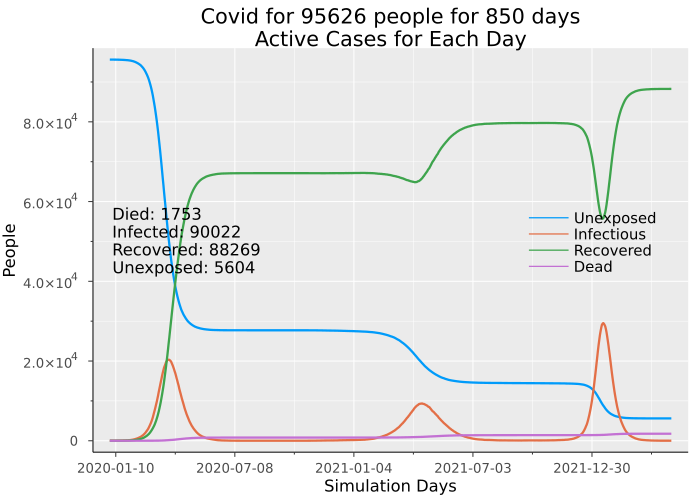

In [87]:
cumplot(series, locale)

Note that the orange line labeled Infectious, which shows the current number of infected people, is *not* what you see in newspaper accounts. In this plot Infectious shows the net infected people: There were some sick people as of the day before. Some more people got sick today. Some people got better: they're not infectious any more--they recovered and are on the blue line. Sadly, some people died--they're not infectious either--they're dead and are on the green line. So net infected is yesterday + new today - recovered today - died today. Newspaper tracking shows the new infections of each day--who got sick today? Tomorrow, if no one new got sick the line would be at zero--even though the people who got sick yesterday aren't better yet. So, the newspaper line goes up and down faster. Yet another approach is to show the cumulative number of infected people: This keeps going up until no one new gets infected--then the line is high but levels off. 

In [ ]:
cumplot(series, locale, [:nil, :mild, :sick, :severe])

In [ ]:
newplot(series, locale, [:dead])

In [ ]:
# png(joinpath(homedir(),"Desktop", "daily change.png"))

In [ ]:
cumplot(series, locale, [:base, :delta, :omicron_ba1, :omicron_ba2])

## Examine Vaccination process and outcomes

In [ ]:
vax = :Pfizer
pfdose2 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 2)
pfdose1 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 1)
println("Count people with $vax 1 dose: $pfdose1 2 doses: $pfdose2 Any: $(pfdose1 + pfdose2)")
println("Doses used = $(2 * pfdose2 + pfdose1)")

In [ ]:
vax = :Moderna
modose2 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 2)
modose1 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 1)
println("Count people with $vax 1 dose: $modose1 2 doses: $modose2 Any: $(modose1 + modose2)")
println("Doses used = $(2 * modose2 + modose1)")

In [ ]:
vax = :JnJ
# jjdose2 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 2)
jjdose1 = count(length.(locdat.vaxrcvd[last.(locdat.vaxrcvd) .== vax]) .== 1)
println("Count people with $vax 1 dose: $jjdose1 Any: $(jjdose1)")
println("Doses used = $(jjdose1)")

In [ ]:
println("People with any vaccine: $(pfdose2+pfdose1+modose2+modose1+jjdose1)")

In [ ]:
newplot(series, locale, [:Pfizer], days=380:700)

In [ ]:
newplot(series, locale, [:Moderna], days=380:700)

In [ ]:
newplot(series, locale, :JnJ, days=380:700)

In [ ]:
newplot(series, locale, :unexposed)




## How many people got sick multiple times?



In [ ]:
sort(countmap(length.(locdat.variant)))

In [ ]:
@Select(vaxday, sickday)(locdat[(last.(locdat.sickday) .> 0) .& (first.(locdat.vaxday).> 0) .& (last.(locdat.sickday) .> first.(locdat.vaxday))], )

## Test a social distancing case

In [ ]:
sd1 = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, include_ages=[])    

In [ ]:
sd1_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, include_ages=[])

In [ ]:
popdat, series = runsim(model;
            dovax=true, vaxscheds=:loc38015, showr0=false, silent=true, 
            runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, seed20_39_omicron, seed40_59_omicron,
                      seed20_39_omicron_ba2, seed40_59_omicron_ba2, sd1, sd1_end]);
locdat = popdat[locale];

In [ ]:
vo=virus_outcome(series, locale, base=:pop)
display(vo)

In [ ]:
sum(values(vo))

In [ ]:
cumplot(series, locale)

In [ ]:
cumplot(series, locale,[:infectious, :dead])

In [ ]:
cumplot(series, locale,[:base, :delta, :omicron_ba1, :omicron_ba2])

## Social distancing only among those age40_59, age60_79, age80_plus

In [ ]:
sdolder = sd_gen(startday = 55, comply=0.9, cf=(.2,1.0), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
sdolder_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age40_59, age60_79, age80_up])    

In [ ]:
popdat, series = runsim(model; 
                        dovax=true, vaxscheds=:loc38015,
                        runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, 
                                  seed20_39_omicron, seed40_59_omicron,
                                  seed20_39_omicron_ba2, seed40_59_omicron_ba2, 
                                  sdolder, sdolder_end]);
locdat = popdat[locale];

In [ ]:
olderdat =popdat[locale]

sd = findall(olderdat.sdcomply .!= :none)

@Select(agegrp, sdcomply)(olderdat[sd])
# @Select(agegrp, sdcomply)(olderdat)

In [ ]:
cumplot(series, locale)

In [ ]:
freemem_plot3 = (Sys.free_memory() / 2^20)

In [ ]:
cumplot(series, locale, [:infectious, :dead])

## Social Distancing starts with everyone and then the younger folks party

In [ ]:
sdyoung_end = sd_gen(startday = 90, comply=0.0, cf=(.2,1.5), tf=(.18,.6), name=:mod_80, 
    include_ages=[age0_19, age20_39])    

In [ ]:
popdat, series = runsim(model,
                        dovax=true, vaxscheds=:loc38015,
                        runcases=[seed20_39_day1, seed40_59_day1, seed20_39_delta, seed40_59_delta, 
                                  seed20_39_omicron, seed40_59_omicron,
                                  seed20_39_omicron_ba2, seed40_59_omicron_ba2, 
                                  sd1, sdyoung_end]);
locdat = popdat[locale];

In [ ]:
freemem_run4 = (Sys.free_memory() / 2^20)

In [ ]:
@show freemem_start freemem_pkg freemem_build freemem_run1 freemem_plot1 freemem_run2 freemem_plot2 freemem_run3 freemem_plot3 freemem_run4

In [ ]:
mixdat = popdat[locale]

sd = findall(mixdat.sdcomply .!= :none)
young = findall((mixdat.agegrp .== age0_19) .| (mixdat.agegrp .== age20_39))
sd_young_idx = intersect(sd, young)
old = findall((mixdat.agegrp .== age40_59) .| (mixdat.agegrp .== age60_79) .| (mixdat.agegrp .== age80_up));

In [ ]:
youngtab = Table(mixdat[young])
count(youngtab.sdcomply .== :none)

In [ ]:
oldtab = Table(mixdat[old])
count(oldtab.sdcomply .!= :none)

In [ ]:
typeof(mixdat.agegrp)

In [ ]:
mixdat = popdat[locale]

In [ ]:
cumplot(series, locale, [:infectious, :dead])

In [ ]:
@Select(status, agegrp, cond, sdcomply)(locdat)